# FINAL fMRI ANALYSIS NOTEBOOK

## Subject-Level Feature Analysis Pipeline

## 1. SETUP

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from scipy.stats import pearsonr

# OPTIONAL: improve plot aesthetics
plt.style.use('default')

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. LOAD DATA

In [6]:
# Folder containing all subject CSV files
BASE_PATH = "/content/drive/MyDrive/CS_4001_Colabs/Final_Project/combined_outputs"

# List of CSV files to combine
csv_files = [
    "caroline_subject_features.csv",
    "scott_subject_features.csv",
    "noor_subject_features.csv"   # Uncomment when available
]

# Load and combine datasets
dfs = []

for file in csv_files:
    path = os.path.join(BASE_PATH, file)

    if os.path.exists(path):
        temp_df = pd.read_csv(path)
        dfs.append(temp_df)

        print(f"Loaded {file}: {temp_df.shape}")
    else:
        print(f"Missing file: {file}")

# Combine all subject data
df = pd.concat(dfs, ignore_index=True)

# Dataset summary
print("\nFinal dataset shape:", df.shape)
print("Number of unique subjects:", df["subject"].nunique())

display(df.head(10))

Loaded caroline_subject_features.csv: (3, 13)
Loaded scott_subject_features.csv: (3, 13)
Loaded noor_subject_features.csv: (3, 13)

Final dataset shape: (9, 13)
Number of unique subjects: 9


,fd_mean,fd_max,fd_std,fd_spikes,dvars_mean,bold_mean_signal,bold_std_signal,bold_mean_voxel_variance,bold_global_mean,bold_global_std,spectral_total_power,spectral_low_freq_power,subject
0,0.203806,0.458892,0.089067,0,1.005190,3071.164839,3174.634520,36699.885607,3071.164839,6.680519,2.246192e+12,2.246189e+12,sub-NDARINVAG339WHH
1,0.246678,0.505903,0.111866,1,1.039142,1669.154344,2481.384973,25962.367727,1669.154344,3.588317,6.634889e+11,6.634880e+11,sub-NDARINVZX212UNE
2,0.322287,1.071488,0.178304,74,1.030614,2260.610718,3267.167161,96428.246386,2260.610718,19.008128,1.217045e+12,1.217030e+12,sub-NDARINVAG023WG3
3,0.115596,0.347291,0.052873,0,1.020287,3605.850481,3821.590934,94917.416144,3605.850481,10.955461,3.096400e+12,3.096393e+12,sub-NDARINVWD338PY2
4,0.315532,1.121469,0.174802,81,1.009975,3354.670270,3217.958352,75522.985125,3354.670270,14.680534,2.680054e+12,2.680040e+12,sub-NDARINVKX727WL8
5,0.125220,1.625480,0.128868,7,1.000285,3040.971678,3253.800562,84923.030373,3040.971678,13.527998,2.202261e+12,2.202254e+12,sub-NDARINVUY799LKJ
6,0.573735,4.444868,0.560604,217,1.044538,3654.995932,3440.685232,258100.580598,3654.995932,48.749396,3.181648e+12,3.181542e+12,sub-NDARINVUR466KN5
7,0.131833,0.716503,0.072154,2,1.067700,4079.434993,4349.548371,86025.753637,4079.434993,15.089044,3.963170e+12,3.963161e+12,sub-NDARINVFH503ZWA
8,0.135581,0.351041,0.061034,0,0.976004,4305.487531,4633.566127,154254.243008,4305.487531,13.238689,4.414549e+12,4.414537e+12,sub-NDARINVJP343BJ6


## 3. BASIC DATA OVERVIEW

In [7]:
print("\nMissing values per column:")
print(df.isnull().sum())

print("\nSummary statistics:")
display(df.describe())


Missing values per column:
fd_mean                     0
fd_max                      0
fd_std                      0
fd_spikes                   0
dvars_mean                  0
bold_mean_signal            0
bold_std_signal             0
bold_mean_voxel_variance    0
bold_global_mean            0
bold_global_std             0
spectral_total_power        0
spectral_low_freq_power     0
subject                     0
dtype: int64

Summary statistics:


,fd_mean,fd_max,fd_std,fd_spikes,dvars_mean,bold_mean_signal,bold_std_signal,bold_mean_voxel_variance,bold_global_mean,bold_global_std,spectral_total_power,spectral_low_freq_power
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000e+00,9.000000e+00
mean,0.241141,1.182548,0.158841,42.444444,1.021526,3226.926754,3515.592915,101426.056512,3226.926754,16.168676,2.629423e+12,2.629404e+12
std,0.148515,1.296282,0.157453,73.285591,0.027340,840.570572,656.626547,69344.969288,840.570572,13.057432,1.208314e+12,1.208307e+12
min,0.115596,0.347291,0.052873,0.000000,0.976004,1669.154344,2481.384973,25962.367727,1669.154344,3.588317,6.634889e+11,6.634880e+11
25%,0.131833,0.458892,0.072154,0.000000,1.005190,3040.971678,3217.958352,75522.985125,3040.971678,10.955461,2.202261e+12,2.202254e+12
50%,0.203806,0.716503,0.111866,2.000000,1.020287,3354.670270,3267.167161,86025.753637,3354.670270,13.527998,2.680054e+12,2.680040e+12
75%,0.315532,1.121469,0.174802,74.000000,1.039142,3654.995932,3821.590934,96428.246386,3654.995932,15.089044,3.181648e+12,3.181542e+12
max,0.573735,4.444868,0.560604,217.000000,1.067700,4305.487531,4633.566127,258100.580598,4305.487531,48.749396,4.414549e+12,4.414537e+12


## 4. MOTION ANALYSIS (CORE RESULT)

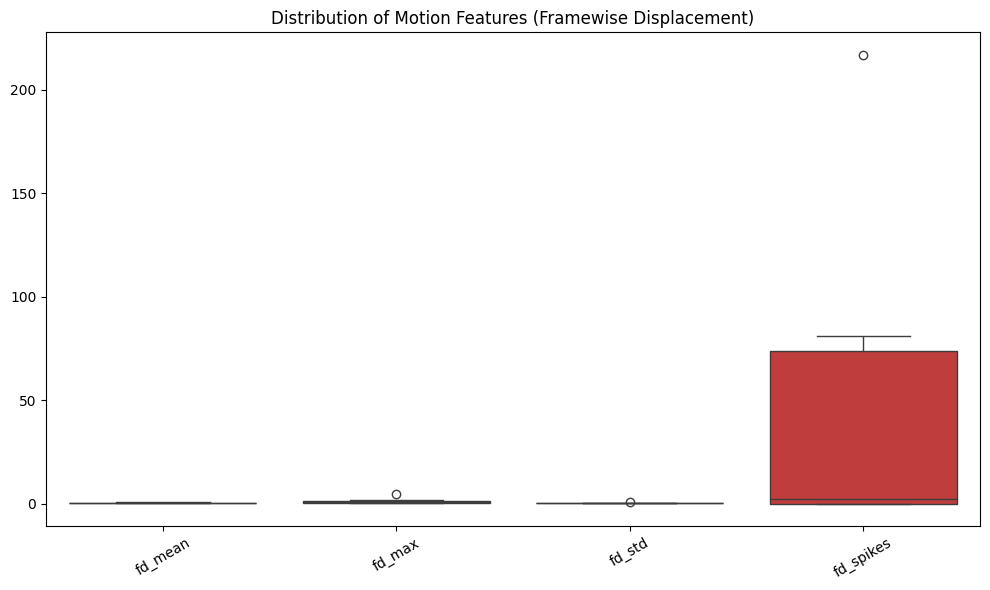

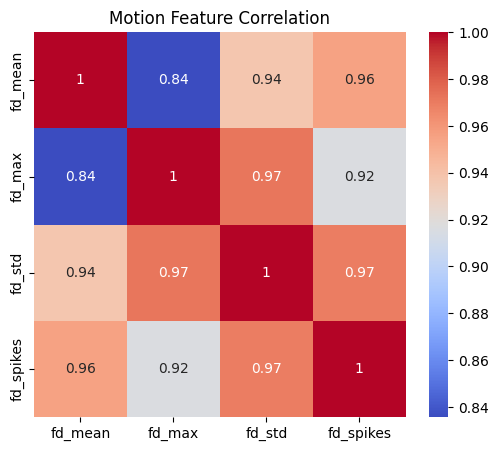

In [8]:
motion_cols = ["fd_mean", "fd_max", "fd_std", "fd_spikes"]

plt.figure(figsize=(10,6))
sns.boxplot(data=df[motion_cols])
plt.title("Distribution of Motion Features (Framewise Displacement)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Correlation between motion features
plt.figure(figsize=(6,5))
sns.heatmap(df[motion_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Motion Feature Correlation")
plt.show()

## 5. DVARS ANALYSIS

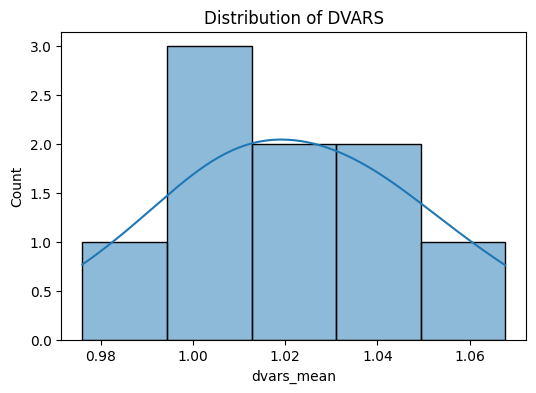

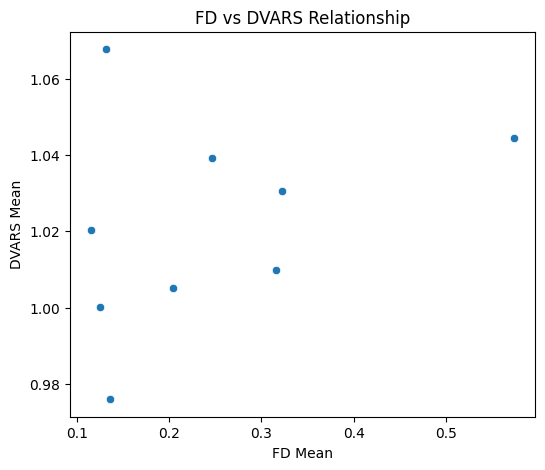

In [9]:
if "dvars_mean" in df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df["dvars_mean"], kde=True)
    plt.title("Distribution of DVARS")
    plt.show()

# FD vs DVARS relationship
if "dvars_mean" in df.columns:
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=df["fd_mean"], y=df["dvars_mean"])
    plt.title("FD vs DVARS Relationship")
    plt.xlabel("FD Mean")
    plt.ylabel("DVARS Mean")
    plt.show()

## 6. BOLD / SIGNAL FEATURES


BOLD-related features: ['bold_mean_signal', 'bold_std_signal', 'bold_mean_voxel_variance', 'bold_global_mean', 'bold_global_std', 'spectral_total_power', 'spectral_low_freq_power']


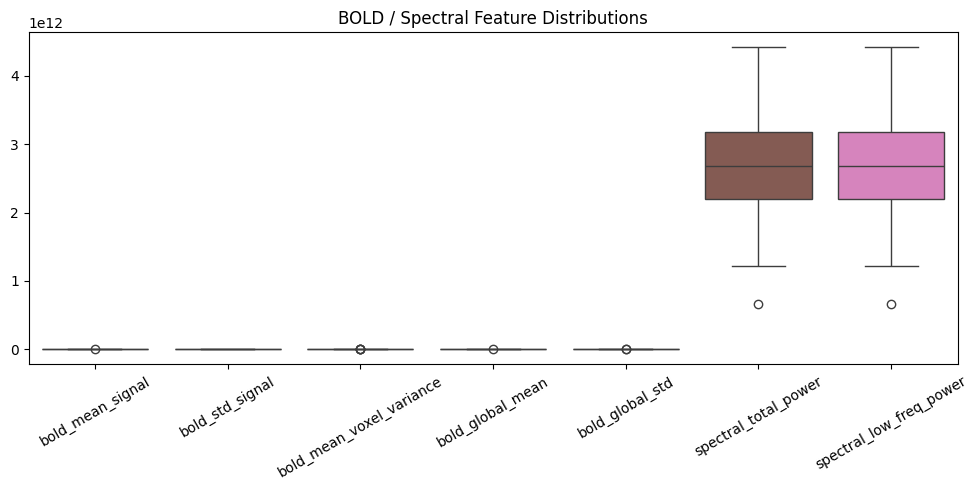

In [10]:
bold_cols = [c for c in df.columns if "bold" in c or "spectral" in c]

print("\nBOLD-related features:", bold_cols)

if len(bold_cols) > 0:
    plt.figure(figsize=(10,5))
    sns.boxplot(data=df[bold_cols])
    plt.xticks(rotation=30)
    plt.title("BOLD / Spectral Feature Distributions")
    plt.tight_layout()
    plt.show()

## 7. FEATURE CORRELATION HEATMAP

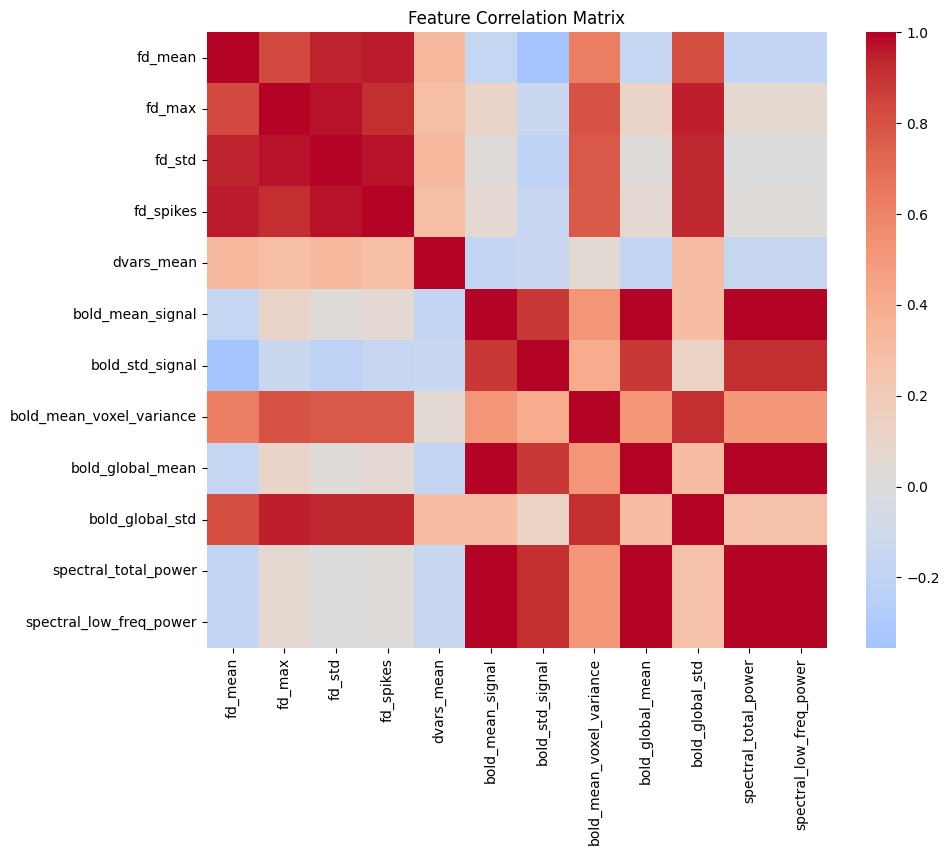

In [11]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

## 8. SIMPLE FEATURE RELATIONSHIPS

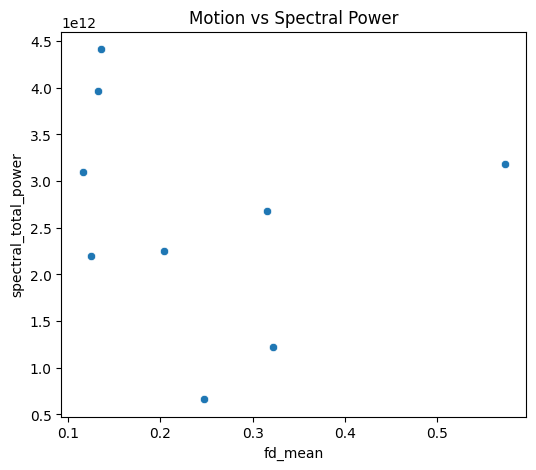

In [12]:
# Example: FD vs spectral power
if "spectral_total_power" in df.columns:
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=df["fd_mean"], y=df["spectral_total_power"])
    plt.title("Motion vs Spectral Power")
    plt.show()

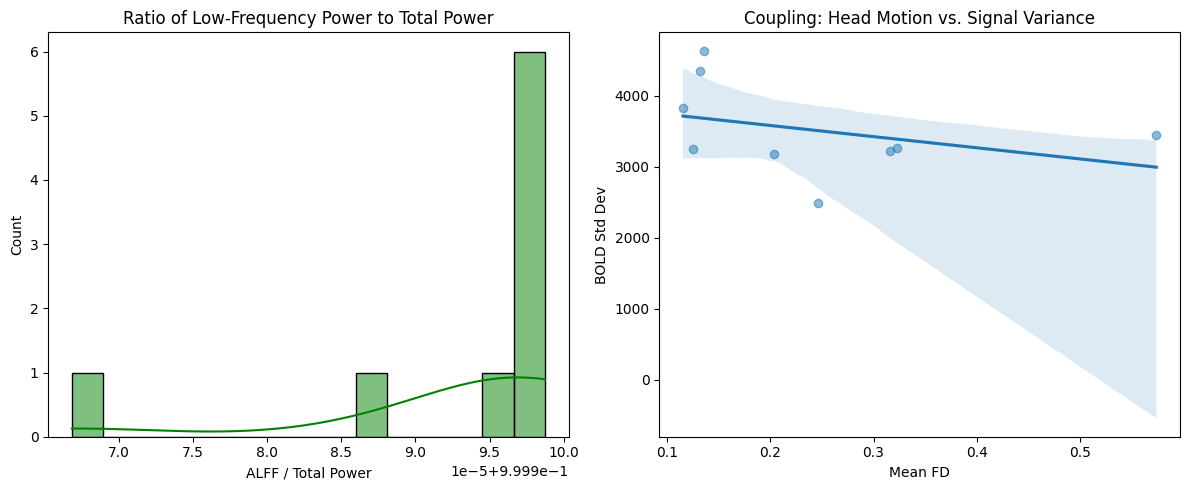

In [13]:
# 7. SPECTRAL / SIGNAL QUALITY ANALYSIS
df['spectral_ratio'] = df['spectral_low_freq_power'] / df['spectral_total_power']

plt.figure(figsize=(12, 5))

# Plot 1: Spectral Ratio
plt.subplot(1, 2, 1)
sns.histplot(df['spectral_ratio'], bins=15, kde=True, color='green')
plt.title("Ratio of Low-Frequency Power to Total Power")
plt.xlabel("ALFF / Total Power")

# Plot 2: Motion-Signal Coupling
plt.subplot(1, 2, 2)
sns.regplot(x=df['fd_mean'], y=df['bold_std_signal'], scatter_kws={'alpha':0.5})
plt.title("Coupling: Head Motion vs. Signal Variance")
plt.xlabel("Mean FD")
plt.ylabel("BOLD Std Dev")

plt.tight_layout()
plt.show()

## 9. OPTIONAL: SIMPLE PREDICTIVE MODEL (IF TARGET EXISTS)

In [14]:
if "FTND" in df.columns:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import r2_score

    target = df["FTND"]
    features = df.drop(columns=["subject", "FTND"], errors="ignore").select_dtypes(include=[np.number])

    X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    print("R2 score:", r2_score(y_test, preds))

    importances = pd.Series(model.feature_importances_, index=features.columns)
    importances.sort_values().plot(kind="barh", figsize=(8,6))
    plt.title("Feature Importance (Random Forest)")
    plt.show()

## 10. EXPORT SUMMARY TABLE

In [15]:
summary = df.describe().T
summary.to_csv("feature_summary_table.csv")

print("Saved summary table: feature_summary_table.csv")

Saved summary table: feature_summary_table.csv


NOTE: I uploaded feature_summary_table.csv as a google sheet in our shared drive if you guys need to use it for the report - Caroline